# Session 3 — Face Landmarks & Face Analysis

### From Facial Landmarks to Meaningful Facial States

**Applied Computer Vision with MediaPipe**

---

In this session you will start with a single face image and progressively discover how to turn raw landmarks into geometric features, facial states, and finally a real-time analyzer.

```mermaid
flowchart TD
    A --> Face Image
    B --> Face Landmark Detection
    C --> Landmark Coordinates
    D --> Facial Geometry
    E --> Geometric Features
    F --> Eye / Mouth States
    G --> Blink Detection
    H --> Facial State
    I --> Real-Time Analyzer
```

**What you will build by the end of this notebook**
- Detect 478 face landmarks with the modern MediaPipe Tasks API
- Convert landmarks into stable geometric features
- Classify eye state (open / closed) using the Eye Aspect Ratio
- Detect blinks as temporal events
- Analyze mouth state
- Combine everything into a simple real-time face-state analyzer


## 1. Connecting to Session 2

In **Session 2** you learned this pipeline:

```
Hand → Landmarks → Geometry → Features → Gesture → Action
```

Today we apply exactly the same idea to faces:

```
Face → Landmarks → Geometry → Features → Facial State → Action
```

**Guiding question**

> If landmarks worked so well for hands, can we use the same idea for faces?

The answer is yes — but the face gives us richer geometry, so we can extract more interesting states (eye open/closed, blinks, mouth open/closed, etc.).


## 2. Face Detection vs Face Landmarks vs Face Recognition

It is important to keep three concepts clearly separated:

| Task | Question it answers | Output |
|------|---------------------|--------|
| **Face Detection** | Where is the face? | Bounding box |
| **Face Landmark Detection** | Where are the important points on the face? | 478 3D points |
| **Face Recognition** | Whose face is this? | Identity / embedding |

**This session focuses exclusively on Face Landmark Analysis.**


## 3. Setup & First Face Landmark Model

We use the **current MediaPipe Tasks API** (`mp.tasks.vision.FaceLandmarker`).

### 3.1 Install & Import


In [ ]:
# Run once if needed
#!pip install mediapipe opencv-python numpy matplotlib pillow --quiet


In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import urllib.request
import mediapipe as mp
from mediapipe.tasks import python
from mediapipe.tasks.python import vision

print("MediaPipe version:", mp.__version__)
print("OpenCV version:", cv2.__version__)


MediaPipe version: 1.0.1
OpenCV version: 5.0.0


### 3.2 Download the Face Landmarker model

We use the official float16 model that outputs 478 landmarks (including irises).


In [3]:
MODEL_URL = "https://storage.googleapis.com/mediapipe-models/face_landmarker/face_landmarker/float16/1/face_landmarker.task"
MODEL_PATH = Path("face_landmarker.task")

if not MODEL_PATH.exists():
    print("Downloading Face Landmarker model...")
    urllib.request.urlretrieve(MODEL_URL, MODEL_PATH)
    print("Download complete.")
else:
    print("Model already present.")
print("Model path:", MODEL_PATH.resolve())


Model already present.
Model path: E:\0-Morteza\python codes\CV\face_landmarker.task


### 3.3 Create the FaceLandmarker


In [4]:
BaseOptions = mp.tasks.BaseOptions
FaceLandmarker = mp.tasks.vision.FaceLandmarker
FaceLandmarkerOptions = mp.tasks.vision.FaceLandmarkerOptions
VisionRunningMode = mp.tasks.vision.RunningMode

options = FaceLandmarkerOptions(
    base_options=BaseOptions(model_asset_path=str(MODEL_PATH)),
    running_mode=VisionRunningMode.IMAGE,
    num_faces=1,
    min_face_detection_confidence=0.5,
    min_face_presence_confidence=0.5,
    min_tracking_confidence=0.5,
    output_face_blendshapes=False,
    output_facial_transformation_matrixes=False,
)

face_landmarker = FaceLandmarker.create_from_options(options)
print("FaceLandmarker ready.")


FaceLandmarker ready.


### 3.4 Load a test image

We start with a single still image so we can inspect every step carefully.


Image shape: (474, 474, 3)


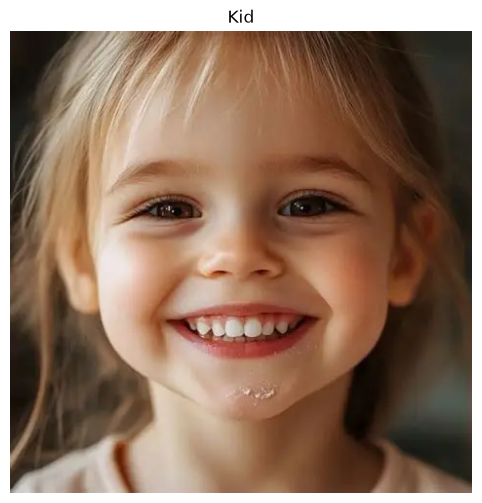

In [11]:
# You can replace this URL with any clear front-facing face image
SAMPLE_IMAGE_URL = "https://storage.googleapis.com/mediapipe-assets/portrait.jpg"
IMAGE_PATH = Path("sample_face.jpg")

if not IMAGE_PATH.exists():
    try:
        urllib.request.urlretrieve(SAMPLE_IMAGE_URL, IMAGE_PATH)
        print("Sample image downloaded.")
    except Exception as e:
        print("Could not download sample image automatically.")
        print("Please place a clear face photo named 'sample_face.jpg' in the working directory.")
        print("Error:", e)


bgr_image = cv2.imread(str(IMAGE_PATH))
rgb_image = cv2.cvtColor(bgr_image, cv2.COLOR_BGR2RGB)

print("Image shape:", rgb_image.shape)

plt.figure(figsize=(8, 6))
plt.imshow(rgb_image)
plt.title("Kid")
plt.axis("off")
plt.show()


### 3.5 Run face landmark detection


In [13]:
# Convert to MediaPipe Image
mp_image = mp.Image(image_format=mp.ImageFormat.SRGB, data=rgb_image)

# Detect
result = face_landmarker.detect(mp_image)

print("Number of faces detected:", len(result.face_landmarks))
if result.face_landmarks:
    print("Number of landmarks on first face:", len(result.face_landmarks[0]))


Number of faces detected: 1
Number of landmarks on first face: 478


## 4. What Did the Model Give Us?

The model returns a list of **NormalizedLandmark** objects.

Each landmark has:
- `x` — horizontal position (0 = left edge, 1 = right edge of the image)
- `y` — vertical position (0 = top edge, 1 = bottom edge of the image)
- `z` — relative depth (smaller = closer to the camera)

Coordinates are **normalized**, so they stay in the range [0, 1] regardless of image resolution.


In [16]:
if not result.face_landmarks:
    raise ValueError("No face detected. Please use a clearer front-facing photo.")

landmarks = result.face_landmarks[0]   # first (and only) face

# Inspect a few meaningful landmarks
interesting = {
    "Nose tip": 4,
    "Chin": 152,
    "Left eye outer": 33,
    "Right eye outer": 263,
    "Mouth left": 61,
    "Mouth right": 291,
    "Upper lip": 13,
    "Lower lip": 14,
}

print(f"{'Landmark':<20} {'Index':>6} {'x':>8} {'y':>8} {'z':>8}")
print("-" * 55)
for name, idx in interesting.items():
    lm = landmarks[idx]
    print(f"{name:<20} {idx:>6} {lm.x:8.4f} {lm.y:8.4f} {lm.z:8.4f}")


Landmark              Index        x        y        z
-------------------------------------------------------
Nose tip                  4   0.4918   0.4856  -0.1804
Chin                    152   0.5073   0.8359  -0.0447
Left eye outer           33   0.2847   0.3972   0.0844
Right eye outer         263   0.7063   0.3867   0.0651
Mouth left               61   0.3406   0.6293   0.0081
Mouth right             291   0.6655   0.6191  -0.0034
Upper lip                13   0.5007   0.6143  -0.0941
Lower lip                14   0.5015   0.6737  -0.0664


**Checkpoint**

> If we know the coordinates of these points, what can we calculate?

Think about distances, ratios, angles, and relative positions.  
That is exactly where we are heading next.


## 5. Visualizing Face Landmarks

### Official MediaPipe Face Landmark Topology

The image below shows the full set of landmarks produced by the model.  
It is the visual reference we will use throughout the lesson.

![MediaPipe Face Landmarks](https://storage.googleapis.com/mediapipe-assets/documentation/mediapipe_face_landmark_fullsize.png)

*Source: Official MediaPipe documentation*

Now let’s draw the landmarks that **our** model just detected.


In [18]:
print(rgb_image.shape)

(474, 474, 3)


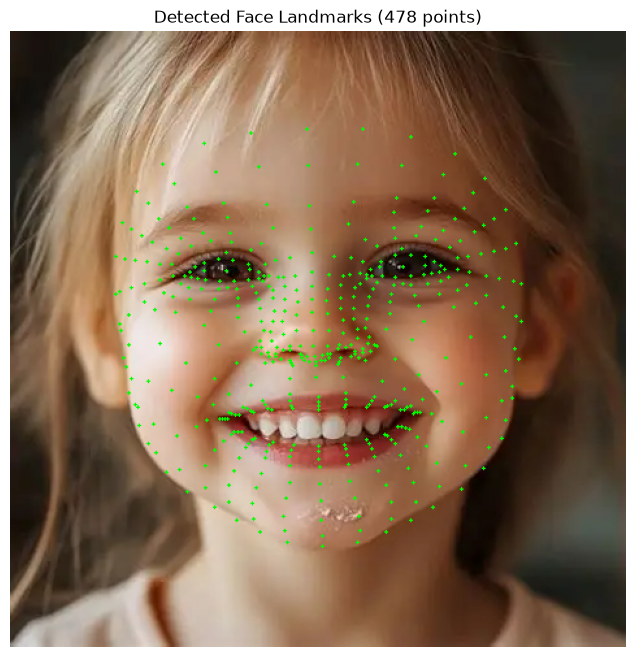

In [23]:
def draw_landmarks_simple(image, landmarks, color=(0, 255, 0), radius=1):
    """Draw all landmarks as small circles."""
    h, w = image.shape[:2]
    out = image.copy()
    for lm in landmarks:
        x = int(lm.x * w)
        y = int(lm.y * h)
        cv2.circle(out, (x, y), radius, color, -1)
    return out

annotated = draw_landmarks_simple(rgb_image, landmarks, color=(0, 255, 0), radius=1)

plt.figure(figsize=(10, 8))
plt.imshow(annotated)
plt.title("Detected Face Landmarks (478 points)")
plt.axis("off")
plt.show()


### Highlighting meaningful regions

Instead of looking at hundreds of points, we focus on a few regions that matter for facial state analysis.


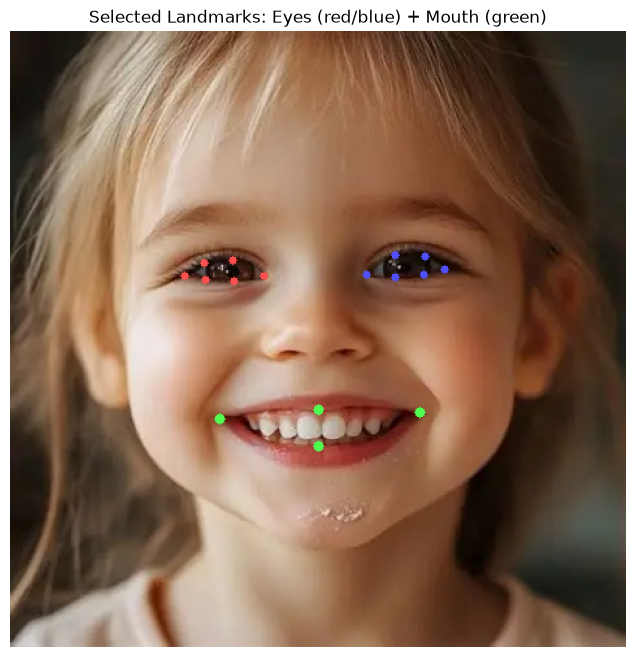

In [24]:
# Key indices we will use later
LEFT_EYE_IDX  = [33, 160, 158, 133, 153, 144]   # for EAR (right eye in image coords often)
RIGHT_EYE_IDX = [362, 385, 387, 263, 373, 380]
MOUTH_IDX     = [61, 291, 13, 14]               # left, right, upper, lower

def draw_selected_points(image, landmarks, indices, color, radius=3, labels=False):
    h, w = image.shape[:2]
    out = image.copy()
    for idx in indices:
        lm = landmarks[idx]
        x, y = int(lm.x * w), int(lm.y * h)
        cv2.circle(out, (x, y), radius, color, -1)
        if labels:
            cv2.putText(out, str(idx), (x+4, y-4),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.35, color, 1)
    return out

vis = rgb_image.copy()
vis = draw_selected_points(vis, landmarks, LEFT_EYE_IDX,  (255, 80, 80), radius=3)
vis = draw_selected_points(vis, landmarks, RIGHT_EYE_IDX, (80, 80, 255), radius=3)
vis = draw_selected_points(vis, landmarks, MOUTH_IDX,     (80, 255, 80), radius=4)

plt.figure(figsize=(10, 8))
plt.imshow(vis)
plt.title("Selected Landmarks: Eyes (red/blue) + Mouth (green)")
plt.axis("off")
plt.show()


**Key insight**

> Hundreds of points → a few meaningful regions.

We do not need every landmark. We only need the ones that help us measure geometry related to eyes and mouth.


## 6. From Landmarks to Geometry

A single landmark is just a point.  
**Multiple landmarks create geometry.**

The most basic geometric measurement is the **Euclidean distance** between two points.


In [ ]:
def distance(p1, p2):
    """Euclidean distance between two landmarks (normalized coordinates)."""
    return np.linalg.norm(
        np.array([p1.x, p1.y]) - np.array([p2.x, p2.y])
    )

# Example: horizontal distance between the outer corners of both eyes
left_outer  = landmarks[33]
right_outer = landmarks[263]
eye_span = distance(left_outer, right_outer)

print(f"Distance between outer eye corners: {eye_span:.4f} (normalized units)")


Distance between outer eye corners: 0.0378 (normalized units)


We can also compute vertical and horizontal components separately when needed.


In [ ]:
def vertical_distance(p1, p2):
    return abs(p1.y - p2.y)

def horizontal_distance(p1, p2):
    return abs(p1.x - p2.x)

print("Vertical distance (nose tip → chin):",
      f"{vertical_distance(landmarks[4], landmarks[152]):.4f}")
print("Horizontal mouth width:",
      f"{horizontal_distance(landmarks[61], landmarks[291]):.4f}")


## 7. Why Ratios Are Better Than Raw Distances

Raw pixel (or normalized) distances change when:
- the person moves closer to the camera
- the person moves farther away
- the image resolution changes

**Ratios** are much more stable because both the numerator and the denominator scale together.

```mermaid
flowchart LR
    A[Raw Distance] --> B[Affected by Scale]
    C[Ratio] --> D[More Scale-Invariant]
```

This idea is the foundation of the **Eye Aspect Ratio (EAR)** and the mouth aspect ratio we will use next.


## 8. Eye Analysis

### Visual intuition

When an eye is **open**, the vertical distance between the upper and lower eyelids is relatively large.  
When an eye is **closed**, that vertical distance becomes very small.


### Relevant eye landmarks

We use six landmarks per eye (standard choice for EAR):

**Right eye (image left side often):**  
`[33, 160, 158, 133, 153, 144]`

**Left eye:**  
`[362, 385, 387, 263, 373, 380]`

```mermaid
flowchart TD
    A[Eye Landmarks] --> B[Vertical distances]
    A --> C[Horizontal distance]
    B --> D[Eye Aspect Ratio]
    C --> D
    D --> E{Threshold}
    E -->|High| F[OPEN]
    E -->|Low| G[CLOSED]
```


In [ ]:
def get_eye_landmarks(landmarks, indices):
    return [landmarks[i] for i in indices]

right_eye = get_eye_landmarks(landmarks, LEFT_EYE_IDX)   # naming follows common EAR convention
left_eye  = get_eye_landmarks(landmarks, RIGHT_EYE_IDX)

print("Right eye landmarks extracted:", len(right_eye))
print("Left eye landmarks extracted:", len(left_eye))


## 9. Eye Aspect Ratio (EAR)

### Intuition

We compare the **average vertical opening** of the eye with its **horizontal width**.

$$
EAR = \frac{\|p_2 - p_6\| + \|p_3 - p_5\|}{2 \cdot \|p_1 - p_4\|}
$$

- Numerator → how open the eye is (vertical)
- Denominator → width of the eye (horizontal)
- When the eye closes, the numerator shrinks → EAR becomes small

### Step-by-step implementation


In [ ]:
def eye_aspect_ratio(eye_landmarks):
    """
    Compute the Eye Aspect Ratio for one eye.
    eye_landmarks must contain 6 points in the order:
    [p1, p2, p3, p4, p5, p6] corresponding to the classic EAR ordering.
    """
    # Vertical distances
    A = distance(eye_landmarks[1], eye_landmarks[5])
    B = distance(eye_landmarks[2], eye_landmarks[4])
    # Horizontal distance
    C = distance(eye_landmarks[0], eye_landmarks[3])
    
    ear = (A + B) / (2.0 * C + 1e-6)   # small epsilon to avoid division by zero
    return ear

# Calculate EAR for both eyes on the current image
ear_right = eye_aspect_ratio(right_eye)
ear_left  = eye_aspect_ratio(left_eye)
ear_avg   = (ear_left + ear_right) / 2.0

print(f"Right eye EAR : {ear_right:.4f}")
print(f"Left eye EAR  : {ear_left:.4f}")
print(f"Average EAR   : {ear_avg:.4f}")


**Checkpoint**

> What happens to the EAR value when the eye closes?  
> Why do we average the two vertical distances?


## 10. Open vs Closed Eye Classification

The EAR gives us a continuous number.  
To turn it into a state we need a **threshold**.

> Important: the threshold is an **experimental parameter**, not a universal constant.  
> Typical values for a frontal face are often around 0.2 – 0.25, but you should verify on your own data.


In [ ]:
# Simple threshold-based classifier
EAR_THRESHOLD = 0.21   # start with this value; adjust later

def is_eye_open(ear, threshold=EAR_THRESHOLD):
    return ear > threshold

eye_state = "OPEN" if is_eye_open(ear_avg) else "CLOSED"
print(f"Average EAR = {ear_avg:.4f}")
print(f"Threshold   = {EAR_THRESHOLD}")
print(f"Eye state   = {eye_state}")


Try changing the threshold and observe how the classification changes.  
This is a good moment to experiment.


In [ ]:
# Quick experiment: see how different thresholds classify the current frame
for thr in [0.15, 0.18, 0.21, 0.25, 0.30]:
    state = "OPEN" if ear_avg > thr else "CLOSED"
    print(f"Threshold {thr:.2f} → {state}")


## 11. Blink Detection

A blink is **not** simply “eye is closed”.

A blink is a **temporal pattern**:

```mermaid
flowchart LR
    A[OPEN] --> B[CLOSED]
    B --> C[OPEN]
    C --> D[BLINK DETECTED]
```

We need to remember the previous state across frames.


In [ ]:
class BlinkDetector:
    """Simple state-machine blink detector."""
    
    def __init__(self, ear_threshold=0.21, min_closed_frames=1):
        self.ear_threshold = ear_threshold
        self.min_closed_frames = min_closed_frames
        self.closed_counter = 0
        self.total_blinks = 0
        self.prev_state = "OPEN"
    
    def update(self, ear):
        current_state = "CLOSED" if ear < self.ear_threshold else "OPEN"
        
        if current_state == "CLOSED":
            self.closed_counter += 1
        else:
            # Eye is open now
            if self.prev_state == "CLOSED" and self.closed_counter >= self.min_closed_frames:
                self.total_blinks += 1
            self.closed_counter = 0
        
        self.prev_state = current_state
        return current_state, self.total_blinks

# Demo with a synthetic sequence of EAR values
demo_ears = [0.28, 0.27, 0.25, 0.18, 0.15, 0.16, 0.22, 0.27, 0.29, 0.14, 0.13, 0.26]
blinker = BlinkDetector(ear_threshold=0.21)

print("Frame | EAR    | State   | Blinks")
print("-" * 35)
for i, ear in enumerate(demo_ears):
    state, count = blinker.update(ear)
    print(f"{i:5d} | {ear:.3f}  | {state:7s} | {count}")


**Checkpoint**

> Is a closed eye always a blink?  
> Why do we require a short sequence of closed frames before counting a blink?


## 12. Mouth Analysis

We apply the same geometric reasoning to the mouth.

### Key landmarks
- Left corner: 61  
- Right corner: 291  
- Upper lip: 13  
- Lower lip: 14  

```mermaid
flowchart TD
    A[Mouth Landmarks] --> B[Mouth Width]
    A --> C[Mouth Height]
    B --> D[Mouth Aspect Ratio]
    C --> D
    D --> E{Threshold}
    E -->|High| F[OPEN]
    E -->|Low| G[CLOSED]
```


In [ ]:
def mouth_aspect_ratio(landmarks):
    """Simple mouth aspect ratio = height / width."""
    left  = landmarks[61]
    right = landmarks[291]
    upper = landmarks[13]
    lower = landmarks[14]
    
    width  = distance(left, right)
    height = distance(upper, lower)
    return height / (width + 1e-6)

mar = mouth_aspect_ratio(landmarks)
print(f"Mouth Aspect Ratio (MAR): {mar:.4f}")


In [ ]:
MOUTH_THRESHOLD = 0.35   # experimental – adjust to your data

def is_mouth_open(mar, threshold=MOUTH_THRESHOLD):
    return mar > threshold

mouth_state = "OPEN" if is_mouth_open(mar) else "CLOSED"
print(f"MAR = {mar:.4f} → Mouth is {mouth_state}")


## 13. Combining Features into a Facial State

We now have:
- Eye state (OPEN / CLOSED)
- Mouth state (OPEN / CLOSED)
- Blink events

We can combine them into a simple facial-state description.


In [ ]:
def get_facial_state(ear, mar, blink_count,
                     ear_thresh=0.21, mar_thresh=0.35):
    eye_state   = "OPEN" if ear > ear_thresh else "CLOSED"
    mouth_state = "OPEN" if mar > mar_thresh else "CLOSED"
    
    state = {
        "eye": eye_state,
        "mouth": mouth_state,
        "blinks": blink_count,
        "description": f"Eyes {eye_state}, Mouth {mouth_state}"
    }
    return state

# Example on the current still image
facial = get_facial_state(ear_avg, mar, blink_count=0)
print(facial)


**Note**  
These states are simple geometric observations.  
They are **not** medical or psychological diagnoses.


## 14. Mini Project — Simple Face State Analyzer (Still Image)

Let’s put everything together for a single image first.


In [ ]:
def analyze_face(rgb_image, landmarker, ear_thresh=0.21, mar_thresh=0.35):
    """Full pipeline for one image."""
    mp_img = mp.Image(image_format=mp.ImageFormat.SRGB, data=rgb_image)
    result = landmarker.detect(mp_img)
    
    if not result.face_landmarks:
        return None, rgb_image
    
    lms = result.face_landmarks[0]
    
    # Eyes
    right_eye = [lms[i] for i in LEFT_EYE_IDX]
    left_eye  = [lms[i] for i in RIGHT_EYE_IDX]
    ear = (eye_aspect_ratio(right_eye) + eye_aspect_ratio(left_eye)) / 2.0
    
    # Mouth
    mar = mouth_aspect_ratio(lms)
    
    # States
    eye_state   = "OPEN" if ear > ear_thresh else "CLOSED"
    mouth_state = "OPEN" if mar > mar_thresh else "CLOSED"
    
    # Visualization
    out = rgb_image.copy()
    h, w = out.shape[:2]
    
    # Draw selected landmarks
    for idx in LEFT_EYE_IDX + RIGHT_EYE_IDX:
        x, y = int(lms[idx].x * w), int(lms[idx].y * h)
        cv2.circle(out, (x, y), 2, (0, 255, 255), -1)
    for idx in [61, 291, 13, 14]:
        x, y = int(lms[idx].x * w), int(lms[idx].y * h)
        cv2.circle(out, (x, y), 3, (0, 255, 0), -1)
    
    # Overlay text
    cv2.putText(out, f"EAR: {ear:.3f} ({eye_state})", (10, 30),
                cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255, 255, 0), 2)
    cv2.putText(out, f"MAR: {mar:.3f} ({mouth_state})", (10, 60),
                cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255, 255, 0), 2)
    
    info = {"ear": ear, "mar": mar, "eye": eye_state, "mouth": mouth_state}
    return info, out

info, annotated = analyze_face(rgb_image, face_landmarker)

plt.figure(figsize=(10, 8))
plt.imshow(annotated)
plt.title(f"Face State → Eyes: {info['eye']}, Mouth: {info['mouth']}")
plt.axis("off")
plt.show()

print(info)


## 15. Real-Time Processing with Webcam

### Image vs Real-Time pipeline

**Still image**
```
Image → Detect → Analyze → Display
```

**Real-time**
```
Frame → Detect → Analyze → Display
  ↑                         ↓
  └────── Next Frame ───────┘
```

```mermaid
flowchart TD
    A[Camera Frame] --> B[Face Landmarks]
    B --> C[Extract Eye & Mouth Landmarks]
    C --> D[Compute EAR & MAR]
    D --> E[Eye State]
    D --> F[Mouth State]
    E --> G[Blink Detector]
    E --> H[Facial State]
    F --> H
    G --> H
    H --> I[Overlay on Frame]
    I --> J[Display]
    J --> A
```


### Important safety notes for notebooks
- Press **q** in the OpenCV window to quit cleanly.
- Always release the camera and destroy windows.
- If the cell seems stuck, interrupt the kernel and run the cleanup cell below.


In [ ]:
# Real-time Face State Analyzer
# -------------------------------------------------
# Run this cell. A window will open.
# Press 'q' to quit safely.

# We need a VIDEO-mode landmarker for smoother tracking
video_options = FaceLandmarkerOptions(
    base_options=BaseOptions(model_asset_path=str(MODEL_PATH)),
    running_mode=VisionRunningMode.VIDEO,
    num_faces=1,
    min_face_detection_confidence=0.5,
    min_face_presence_confidence=0.5,
    min_tracking_confidence=0.5,
)

video_landmarker = FaceLandmarker.create_from_options(video_options)

cap = cv2.VideoCapture(0)   # change to 1 if you have multiple cameras
if not cap.isOpened():
    print("Cannot open webcam. Check permissions / camera index.")
else:
    blink_detector = BlinkDetector(ear_threshold=0.21)
    frame_timestamp_ms = 0
    
    print("Webcam started. Press 'q' in the window to quit.")
    
    while True:
        ret, frame = cap.read()
        if not ret:
            break
        
        # Flip for selfie view
        frame = cv2.flip(frame, 1)
        rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        mp_frame = mp.Image(image_format=mp.ImageFormat.SRGB, data=rgb)
        
        result = video_landmarker.detect_for_video(mp_frame, frame_timestamp_ms)
        frame_timestamp_ms += 33   # approximate 30 fps
        
        ear = None
        mar = None
        eye_state = "—"
        mouth_state = "—"
        blinks = blink_detector.total_blinks
        
        if result.face_landmarks:
            lms = result.face_landmarks[0]
            
            right_eye = [lms[i] for i in LEFT_EYE_IDX]
            left_eye  = [lms[i] for i in RIGHT_EYE_IDX]
            ear = (eye_aspect_ratio(right_eye) + eye_aspect_ratio(left_eye)) / 2.0
            mar = mouth_aspect_ratio(lms)
            
            eye_state, blinks = blink_detector.update(ear)
            mouth_state = "OPEN" if mar > 0.35 else "CLOSED"
            
            # Draw a few landmarks
            h, w = frame.shape[:2]
            for idx in LEFT_EYE_IDX + RIGHT_EYE_IDX + [61, 291, 13, 14]:
                x, y = int(lms[idx].x * w), int(lms[idx].y * h)
                cv2.circle(frame, (x, y), 2, (0, 255, 0), -1)
        
        # Overlay
        y0 = 30
        cv2.putText(frame, f"Eye: {eye_state}", (10, y0),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.8, (255, 0, 0), 2)
        cv2.putText(frame, f"Mouth: {mouth_state}", (10, y0+35),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.8, (255, 0, 0), 2)
        cv2.putText(frame, f"Blinks: {blinks}", (10, y0+70),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.8, (255, 0, 0), 2)
        if ear is not None:
            cv2.putText(frame, f"EAR: {ear:.3f}", (10, y0+105),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.6, (200, 100, 100), 1)
        
        cv2.imshow("Face State Analyzer — press q to quit", frame)
        
        if cv2.waitKey(1) & 0xFF == ord('q'):
            break
    
    cap.release()
    cv2.destroyAllWindows()
    video_landmarker.close()
    print(f"Session ended. Total blinks detected: {blink_detector.total_blinks}")


In [ ]:
# Cleanup cell (run if the webcam cell was interrupted)
try:
    cap.release()
except:
    pass
cv2.destroyAllWindows()
print("Resources released.")


## 16. Real-World Applications

The techniques you just learned appear in many practical systems:

- **Touchless interfaces** — control a UI with blinks or mouth gestures
- **Accessibility tools** — alternative input methods for users with limited mobility
- **Human-computer interaction** — attention-aware interfaces
- **Camera / video effects** — reactive filters, avatars, AR lenses
- **Experimental attention / drowsiness monitoring**

> **Important disclaimer**  
> A simple eye-closure detector **cannot** reliably diagnose fatigue, sleepiness, or any medical condition.  
> The system we built is an educational demonstration of geometric face analysis, not a clinical tool.


## 17. Failure Cases & Robustness

Computer vision systems are not perfect. Common failure modes:

| Situation | Typical effect |
|-----------|----------------|
| Strong head rotation | Landmarks become inaccurate or disappear |
| Face too far from camera | Low resolution → noisy geometry |
| Poor lighting | Detection confidence drops |
| Glasses / reflections | Eye landmarks can jump |
| Partial occlusion | Missing or wrong points |
| Very fast movement | Tracking lag |
| Extreme facial expression | Thresholds may no longer fit |

```mermaid
flowchart LR
    subgraph Good
        A1[Good Input] --> B1[Reliable Landmarks]
        B1 --> C1[Stable Features]
        C1 --> D1[Correct State]
    end
    subgraph Poor
        A2[Poor Input] --> B2[Noisy Landmarks]
        B2 --> C2[Unstable Features]
        C2 --> D2[Unreliable State]
    end
```

**Practical advice**
- Always check detection confidence when possible
- Keep thresholds adjustable
- Test under the lighting and distances you expect in the real application


## 18. Challenges

### Beginner
Add a third facial state of your choice (for example “eyebrows raised” or “smiling”) using additional landmarks and a simple ratio or distance.

### Intermediate
Improve the blink counter:
- Ignore very short closures (noise)
- Display blinks-per-minute
- Reset the counter with a keyboard key

### Advanced
Build a simple **touchless interaction**:
- Blink once → toggle a virtual button
- Mouth open → change a color or trigger an action
- Combine eye + mouth states into a small gesture vocabulary

Do not look for a complete solution immediately.  
Reuse the functions you already wrote (`distance`, `eye_aspect_ratio`, `BlinkDetector`, etc.).


## 19. Final Conceptual Summary

### Session 2 vs Session 3

| Session 2          | Session 3              |
|--------------------|------------------------|
| Hand               | Face                   |
| Landmarks          | Landmarks              |
| Geometry           | Geometry               |
| Features           | Features               |
| Gesture            | Facial State           |
| Action             | Action                 |

### The complete pipeline you built

```mermaid
flowchart TD
    A[IMAGE] --> B[FACE]
    B --> C[LANDMARKS]
    C --> D[FACIAL GEOMETRY]
    D --> E[FEATURES]
    E --> F[EYE / MOUTH STATES]
    F --> G[BLINK EVENTS]
    G --> H[FACIAL STATE]
    H --> I[REAL-TIME APPLICATION]
```

### Core idea to remember

> **AI gives us landmarks.**  
> We turn landmarks into geometry,  
> geometry into features,  
> features into states,  
> and states into actions.

That is the essence of applied computer vision with MediaPipe.


---

### Next steps (optional)

- Experiment with blendshapes (`output_face_blendshapes=True`) for richer expression signals
- Combine face + hand landmarks (Holistic Landmarker) for full upper-body interaction
- Explore more stable features (e.g., normalized by inter-ocular distance)

**Congratulations on completing Session 3!**
